# **0. Setup (Run Me First)**

**This section must be run before any script section below.** It imports all required
libraries (NumPy, pandas, matplotlib, SciPy, ipywidgets, IPython display, Colab files) and
defines plate-layout helpers (`load_384_table`, `reshape_to_plate`, `time_scroller`) used
by Script 1. After running this once, you can run any of the four scripts (1-4) below
independently.

In [1]:
# @title 0. Setup (run me first)
# --- Imports (shared by every script section below) ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from IPython.display import display, Markdown
from google.colab import files
import ipywidgets as widgets
from scipy.optimize import curve_fit
from scipy.stats import linregress, f as f_dist, t as t_dist
from scipy.interpolate import interp1d

# --- Plate layout helpers ---
ROWS = list("ABCDEFGHIJKLMNOP")         # 16 rows
COLS = list(range(1, 25))               # 24 cols
EXPECTED_WELLS = [f"{r}{c}" for r in ROWS for c in COLS]  # A1..A24 ... P1..P24

def _read_table(path):
    ext = os.path.splitext(path)[1].lower()

    # Excel files: pick the sheet with the most well headers
    if ext in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(path)
        best_sheet, best_count = None, -1
        for sh in xls.sheet_names:
            try:
                tmp = pd.read_excel(xls, sheet_name=sh, nrows=3)
            except Exception:
                continue
            cols = [str(c).strip() for c in tmp.columns]
            count = sum(c in EXPECTED_WELLS for c in cols)
            if count > best_count:
                best_sheet, best_count = sh, count
        return pd.read_excel(xls, sheet_name=best_sheet)

    # CSV/TSV/TXT files
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "," if ext == ".csv" else ("\t" if ext == ".tsv" else None)
        return pd.read_csv(path, sep=sep)

    else:
        raise ValueError("Unsupported file type (use .xlsx, .xls, .csv, .tsv, or .txt)")

def load_384_table(path_or_df):
    """Returns (df_ordered, wells_list).
    - Rows = time points
    - Columns = wells A1..A24 ... P1..P24 (reordered; extras ignored)
    - If time is in columns (384 rows), auto-transpose.
    """
    if isinstance(path_or_df, pd.DataFrame):
        df = path_or_df.copy()
    else:
        df = _read_table(path_or_df)

    df.columns = [str(c).strip() for c in df.columns]

    # If wells are rows, flip so time is rows
    if df.shape[0] == 384 and df.shape[1] != 384:
        df = df.transpose()
        df.columns = [str(c).strip() for c in df.columns]

    present = [w for w in EXPECTED_WELLS if w in df.columns]
    if not present:
        raise ValueError("Did not find well headers like 'A1'...'P24'.")
    if len(present) < 384:
        missing = [w for w in EXPECTED_WELLS if w not in df.columns]
        display(Markdown(f"**Warning:** {len(missing)} wells missing. First few: {missing[:10]}"))

    return df[present].copy(), present


def reshape_to_plate(row_values, wells_order):
    """1D vector (len <= 384) -> 16x24 array in A..P x 1..24 order."""
    plate = np.full((len(ROWS), len(COLS)), np.nan, float)
    grid = np.array(EXPECTED_WELLS).reshape(len(ROWS), len(COLS))
    series = pd.Series(row_values, index=wells_order)
    for i in range(len(ROWS)):
        for j in range(len(COLS)):
            label = grid[i, j]
            if label in series.index:
                plate[i, j] = series[label]
    return plate

def time_scroller(df, wells_order, title, vmin=None, vmax=None, unit="RFU"):
    """Interactive heatmap per time index."""
    stack = np.asarray([reshape_to_plate(df.iloc[t].values, wells_order) for t in range(len(df))])
    if vmin is None: vmin = np.nanmin(stack)
    if vmax is None: vmax = np.nanmax(stack)

    def _draw(t):
        fz = 25
        fig, ax = plt.subplots(figsize=(9, 4.8), dpi=100)
        im = ax.imshow(stack[t], aspect='equal', vmin=vmin, vmax=vmax)

        c = fig.colorbar(im, ax=ax)
        c.set_label(unit, fontsize=fz)
        c.ax.tick_params(labelsize=fz)

        ax.set_title(f"{title} | t = {t}", fontsize=fz)
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("Column (1->24)", fontsize=fz)
        ax.set_ylabel("Row (P<-A)", fontsize=fz)

    widgets.interact(_draw, t=widgets.IntSlider(0, min=0, max=max(0, len(df)-1), step=1, description="time"))

print("Setup complete. Helpers ready: load_384_table, reshape_to_plate, time_scroller.")


Setup complete. Helpers ready: load_384_table, reshape_to_plate, time_scroller.


# **1. Script 1: Flat-field and background correction**

Loads three 384-well plate spreadsheets (background, flat-field, raw experiment), aligns
them by common wells and time length, computes the corrected image at each time step, and
lets you download the result.

**Correction formula:** `I_corr(t) = I_BG(t) + I_RAW(t) * (I_FF(t) - I_BG(t))`

## 1.1 Upload background file

In [2]:
# @title
print("Upload your BACKGROUND (BG) spreadsheet:")
uploaded = files.upload()  # dictionary: {filename: filecontent}
BG_filename = list(uploaded.keys())[0]  # take the first uploaded file
print("BG file set to:", BG_filename)
BG, BG_wells = load_384_table(BG_filename)
display(Markdown(f"**BG loaded:** {BG.shape[0]} time points × {BG.shape[1]} wells"))
# display(BG.head()) # show the first 5 rows for a quick check
display(BG.tail()) # show the last 5 rows for a quick check
time_scroller(BG, BG_wells, title="Background image $I_{BG}(t)$", unit="RFU (/10$^{2}$)")

Upload your BACKGROUND (BG) spreadsheet:


Saving Background.xlsx to Background (1).xlsx
BG file set to: Background (1).xlsx


**BG loaded:** 51 time points × 384 wells

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24
46,3204.911607,3306.389027,3383.255124,3410.451817,3392.842077,3387.697547,3390.642199,3355.311957,3448.905232,3370.553889,...,3388.985376,3336.553745,3385.610406,3275.915133,3345.021288,3259.428026,3330.052597,3263.084270,3324.193713,3365.766456
47,3206.358381,3310.603417,3381.606896,3407.364074,3393.089904,3384.358160,3388.569700,3356.129347,3447.561228,3369.958922,...,3391.050130,3338.302000,3385.265477,3276.570298,3348.602550,3262.820145,3332.127543,3262.848876,3322.378742,3365.878849
48,3207.000862,3307.700457,3386.646285,3414.012273,3395.471023,3386.530313,3388.478394,3359.469720,3451.926106,3371.629082,...,3390.367728,3335.657736,3383.770275,3276.932539,3349.510378,3264.611326,3335.680711,3266.817160,3327.690129,3371.837020
49,3204.458123,3306.715380,3380.210670,3412.753224,3397.146609,3387.876664,3389.199578,3358.631705,3450.377029,3372.159654,...,3392.158613,3336.609023,3387.121307,3275.448580,3348.617470,3261.392124,3332.655033,3260.214252,3327.048237,3369.959365
50,3205.069548,3308.389017,3386.004179,3411.707641,3397.556128,3388.274363,3388.671097,3358.219493,3452.992652,3371.739408,...,3391.534443,3338.340855,3389.020167,3278.331720,3350.342500,3262.229051,3332.793196,3267.030575,3327.494096,3370.386949


interactive(children=(IntSlider(value=0, description='time', max=50), Output()), _dom_classes=('widget-interac…

## 1.2 Upload flat-field file

In [3]:
# @title
print("Upload your FLAT-FIELD (FF) spreadsheet…")
uploaded = files.upload()  # dictionary: {filename: filecontent}
FF_filename = list(uploaded.keys())[0]  # take the first uploaded file
FF, FF_wells = load_384_table(FF_filename)
display(Markdown(f"**FF loaded:** {FF.shape[0]} time points × {FF.shape[1]} wells"))
# display(FF.head())
display(FF.tail())
time_scroller(FF, FF_wells, title="Flat-field image $I_{FF}(t)$", unit="RFU (/10$^{3}$)")


Upload your FLAT-FIELD (FF) spreadsheet…


Saving Flatfield.xlsx to Flatfield (1).xlsx


**FF loaded:** 51 time points × 384 wells

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24
46,73004.439970,72321.908678,72990.900402,73087.705815,73135.521047,72340.645308,71520.177509,70210.899193,70211.000508,66255.445032,...,64819.189391,63323.143719,63323.481092,62867.208660,63422.555573,62456.027991,62274.092451,61787.888740,61787.075863,61658.663488
47,73004.422437,72321.855457,72990.913607,73087.785201,73135.693047,72340.657419,71520.132297,70210.857067,70210.768416,66255.419101,...,64819.196628,63323.117930,63323.341581,62867.088220,63422.526117,62455.881500,62274.046669,61787.938543,61786.974175,61658.535984
48,73004.888219,72322.153892,72991.277469,73088.020161,73135.881024,72341.047799,71520.538168,70211.011352,70211.175988,66255.521983,...,64819.264732,63323.111019,63323.410485,62867.006545,63422.488226,62455.843217,62273.995103,61787.642467,61786.774166,61658.597833
49,73004.585224,72321.921291,72990.997389,73087.679178,73135.630669,72340.757997,71520.400954,70210.817486,70210.741500,66255.509694,...,64819.358349,63323.094151,63323.473221,62867.184907,63422.702735,62455.999519,62274.184442,61787.994177,61787.007639,61658.762124
50,73004.606996,72321.931422,72990.931151,73087.894911,73135.732221,72340.942378,71520.442190,70210.937098,70210.882219,66255.403400,...,64819.337523,63322.998927,63323.446230,62867.144751,63422.676155,62456.129642,62274.030201,61787.883275,61787.099957,61658.813117


interactive(children=(IntSlider(value=0, description='time', max=50), Output()), _dom_classes=('widget-interac…

## 1.3 Upload raw data file

In [5]:
# @title
print("Upload your RAW spreadsheet…")
uploaded = files.upload()  # dictionary: {filename: filecontent}
RAW_filename = list(uploaded.keys())[0]  # take the first uploaded file
RAW, RAW_wells = load_384_table(RAW_filename)
display(Markdown(f"**RAW loaded:** {RAW.shape[0]} time points × {RAW.shape[1]} wells"))
# display(RAW.head())
display(RAW.tail())
time_scroller(RAW, RAW_wells, title="Corrected image $I_{RAW}(t)$", unit="RFU")


Upload your RAW spreadsheet…


Saving RawData.xlsx to RawData (1).xlsx


**Warning:** 363 wells missing. First few: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']

**RAW loaded:** 51 time points × 21 wells

,D6,D7,D8,F6,F7,F8,H6,H7,H8,J6,...,J8,L6,L7,L8,N6,N7,N8,P6,P7,P8
46,39251.951468,40590.407576,40618.145032,20641.637586,21139.521519,19604.158729,11114.665416,11010.651190,10739.322135,6352.282217,...,6294.251812,4581.028267,4484.774585,4533.502970,3870.821814,3783.827137,3824.907452,3629.712992,4145.026223,3646.206901
47,39682.220259,41046.642656,41062.094504,20836.791208,21341.216908,19785.897784,11200.372431,11092.858495,10815.828289,6393.555003,...,6327.686084,4598.038477,4496.088812,4542.420152,3878.110791,3789.718946,3833.372218,3631.007951,4149.649513,3651.615154
48,40205.857385,41530.235971,41545.814981,21028.304262,21521.405667,19968.955071,11274.044901,11163.630770,10887.544116,6413.803523,...,6345.957821,4612.202114,4511.567582,4557.859223,3885.711698,3795.684106,3838.753304,3637.716774,4148.485472,3654.386167
49,40635.936319,42010.024485,42014.730246,21186.280877,21694.491121,20122.344807,11327.844555,11229.313475,10952.854405,6438.511347,...,6378.576485,4622.695742,4524.823671,4570.971223,3891.544008,3802.507615,3849.466282,3637.766932,4157.834716,3659.605674
50,41037.609100,42440.894700,42486.082805,21323.219660,21836.315291,20266.163403,11398.909646,11285.615666,11014.820197,6473.369528,...,6412.984490,4635.891685,4537.819079,4585.932574,3898.682852,3806.900652,3852.233913,3641.522818,4157.357088,3658.665441


interactive(children=(IntSlider(value=0, description='time', max=50), Output()), _dom_classes=('widget-interac…

## 1.4 Correct for flat-field and background

In [6]:
# @title
# Align all three by common wells and common time length
common_wells = [w for w in EXPECTED_WELLS if (w in BG.columns and w in FF.columns and w in RAW.columns)]
if len(common_wells) < 200:
    display(Markdown(f"**Warning:** only {len(common_wells)} common wells found."))
BGc = BG[common_wells]
FFc = FF[common_wells]
RAWc = RAW[common_wells]

T = min(len(BGc), len(FFc), len(RAWc))
if T < len(RAWc) or T < len(BGc) or T < len(FFc):
    display(Markdown(f"Truncating to **{T}** time points to match lengths."))

BGc = BGc.iloc[:T].reset_index(drop=True)
FFc = FFc.iloc[:T].reset_index(drop=True)
RAWc = RAWc.iloc[:T].reset_index(drop=True)

# Vectorized correction with small epsilon to avoid divide-by-zero
eps = 1e-12
Corrected = (RAWc - BGc) / (FFc - BGc + eps)

display(Markdown(f"**Corrected computed:** {Corrected.shape[0]} time points × {Corrected.shape[1]} wells"))
# display(Corrected.head())
display(Corrected.tail())
# Typical corrected range is around 0..1; set a friendly default color scale
time_scroller(Corrected, common_wells, title="Raw image $I_{corr}(t)$", unit="(A.U.)")


**Warning:** only 21 common wells found.

**Corrected computed:** 51 time points × 21 wells

,D6,D7,D8,F6,F7,F8,H6,H7,H8,J6,...,J8,L6,L7,L8,N6,N7,N8,P6,P7,P8
46,0.530118,0.556599,0.563030,0.270725,0.280142,0.255852,0.125231,0.123543,0.119281,0.048946,...,0.048809,0.021504,0.020421,0.021048,0.010439,0.009735,0.010198,0.005735,0.005595,0.005532
47,0.536444,0.563410,0.569711,0.273722,0.283272,0.258677,0.126655,0.124859,0.120496,0.049594,...,0.049350,0.021812,0.020635,0.021199,0.010570,0.009804,0.010262,0.005774,0.005682,0.005597
48,0.544161,0.570599,0.577009,0.276723,0.286129,0.261507,0.127777,0.125984,0.121596,0.049865,...,0.049617,0.022041,0.020785,0.021471,0.010672,0.009944,0.010422,0.005796,0.005624,0.005654
49,0.550511,0.577760,0.584095,0.279184,0.288799,0.263962,0.128654,0.127012,0.122638,0.050284,...,0.050183,0.022200,0.021007,0.021629,0.010767,0.010018,0.010600,0.005811,0.005719,0.005685
50,0.556425,0.584189,0.591178,0.281311,0.291033,0.266178,0.129764,0.127903,0.123620,0.050820,...,0.050687,0.022361,0.021200,0.021874,0.010849,0.010073,0.010549,0.005869,0.005779,0.005655


interactive(children=(IntSlider(value=0, description='time', max=50), Output()), _dom_classes=('widget-interac…

## 1.5 Download the corrected data

In [7]:
# @title
# Saves the `Corrected` DataFrame (computed in 1.4) to an .xlsx file and
# triggers a browser download. The browser's download dialog determines the
# final save location on your local machine (Colab cannot pick an OS folder).

default_name = "corrected_data.xlsx"
user_name = input(f"Filename for download [{default_name}]: ").strip()
out_name = user_name if user_name else default_name
if not out_name.lower().endswith((".xlsx", ".xls")):
    out_name += ".xlsx"

Corrected.to_excel(out_name, index=False)
print(f"Saved to '{out_name}' ({Corrected.shape[0]} rows x {Corrected.shape[1]} cols).")
print("Browser download is starting now; choose the location in your browser's save dialog.")
files.download(out_name)


Filename for download [corrected_data.xlsx]: corrected_data
Saved to 'corrected_data.xlsx' (51 rows x 21 cols).
Browser download is starting now; choose the location in your browser's save dialog.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **2. Script 2: Reporter calibration**

Fits the calibration model `I_corr = 10^(-S0/c0) * (Fcl*P + Fucl*S)` to a calibration
spreadsheet (columns `c`, `cleaved`, `uncleaved`) to extract the per-molecule fluorescence
constants `Fcl`, `Fucl` and the inner-filter scale `c0`. Section 2.3 reports the boundaries
of the three operational regimes implied by `c0`.

## 2.1 Upload calibration file

In [2]:
# @title
print("Upload your calibration spreadsheet…")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read Excel
df = pd.read_excel(filename)

# Remove unnamed index columns if present
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

print("Columns found:", df.columns.tolist())

# Required columns
required_cols = ['c', 'cleaved', 'uncleaved']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Keep only needed columns and clean
df = df[['c', 'cleaved', 'uncleaved']].copy()
df['c'] = pd.to_numeric(df['c'], errors='coerce')
df['cleaved'] = pd.to_numeric(df['cleaved'], errors='coerce')
df['uncleaved'] = pd.to_numeric(df['uncleaved'], errors='coerce')
df = df.dropna().reset_index(drop=True)

print("\nCleaned calibration data:")
display(df)

Upload your calibration spreadsheet…


Saving Reporter_calibration.xlsx to Reporter_calibration (1).xlsx
Columns found: ['c', 'cleaved', 'uncleaved']

Cleaned calibration data:


,c,cleaved,uncleaved
0,666.666667,0.574331,0.015248
1,333.333333,0.326928,0.008919
2,166.666667,0.187498,0.004726
3,83.333333,0.105159,0.002591
4,41.666667,0.050051,0.001342
5,20.833333,0.023919,0.001022
6,10.416667,0.011784,0.000849
7,5.208333,0.003197,0.000036


## 2.2 Extract signal-to-concentration conversion

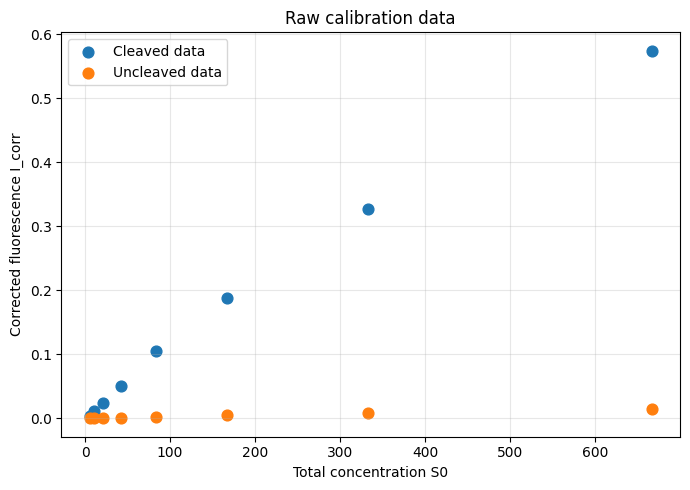

Fitted parameters:
Fcl  = 0.0011864 ± 2.2e-05
Fucl = 3.1575e-05 ± 7.28e-06
c0   = 4741.46 ± 316


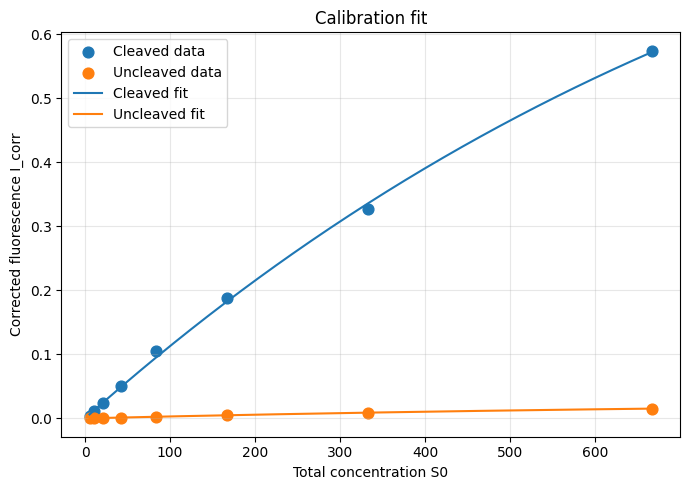

,Parameter,Value,Std_Error
0,Fcl,0.001186,0.000022
1,Fucl,0.000032,0.000007
2,c0,4741.464037,315.768130



Saved results to: calibration_fit_results.xlsx


In [3]:
# @title
# Extract arrays
S0 = df['c'].values
I_cleaved = df['cleaved'].values
I_uncleaved = df['uncleaved'].values

# -------------------------
# 1. Plot raw calibration data
# -------------------------
plt.figure(figsize=(7, 5))
plt.scatter(S0, I_cleaved, s=60, label='Cleaved data')
plt.scatter(S0, I_uncleaved, s=60, label='Uncleaved data')
plt.xlabel('Total concentration S0')
plt.ylabel('Corrected fluorescence I_corr')
plt.title('Raw calibration data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 2. Define fitting model
# I_corr = 10^(-S0/c0) * (Fcl*P + Fucl*S)
# -------------------------
def calibration_model(X, Fcl, Fucl, c0):
    S0, P, S = X
    return (10 ** (-S0 / c0)) * (Fcl * P + Fucl * S)

# Build combined dataset
# Cleaved:   P = S0, S = 0
# Uncleaved: P = 0,  S = S0
S0_all = np.concatenate([S0, S0])
P_all  = np.concatenate([S0, np.zeros_like(S0)])
S_all  = np.concatenate([np.zeros_like(S0), S0])
I_all  = np.concatenate([I_cleaved, I_uncleaved])

# -------------------------
# 3. Initial guesses
# -------------------------
Fcl_guess = np.max(I_cleaved / S0)
Fucl_guess = np.max(I_uncleaved / S0)
c0_guess = np.median(S0)

p0 = [Fcl_guess, Fucl_guess, c0_guess]
bounds = ([0, 0, 1e-12], [np.inf, np.inf, np.inf])

# -------------------------
# 4. Fit parameters
# -------------------------
popt, pcov = curve_fit(
    calibration_model,
    (S0_all, P_all, S_all),
    I_all,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

Fcl_fit, Fucl_fit, c0_fit = popt
perr = np.sqrt(np.diag(pcov))
Fcl_err, Fucl_err, c0_err = perr

print("Fitted parameters:")
print(f"Fcl  = {Fcl_fit:.6g} ± {Fcl_err:.3g}")
print(f"Fucl = {Fucl_fit:.6g} ± {Fucl_err:.3g}")
print(f"c0   = {c0_fit:.6g} ± {c0_err:.3g}")

# -------------------------
# 5. Plot fitted curves
# -------------------------
S0_fit = np.linspace(np.min(S0), np.max(S0), 300)

I_cleaved_fit = calibration_model(
    (S0_fit, S0_fit, np.zeros_like(S0_fit)),
    Fcl_fit, Fucl_fit, c0_fit
)

I_uncleaved_fit = calibration_model(
    (S0_fit, np.zeros_like(S0_fit), S0_fit),
    Fcl_fit, Fucl_fit, c0_fit
)

plt.figure(figsize=(7, 5))
plt.scatter(S0, I_cleaved, s=60, label='Cleaved data')
plt.scatter(S0, I_uncleaved, s=60, label='Uncleaved data')
plt.plot(S0_fit, I_cleaved_fit, label='Cleaved fit')
plt.plot(S0_fit, I_uncleaved_fit, label='Uncleaved fit')
plt.xlabel('Total concentration S0')
plt.ylabel('Corrected fluorescence I_corr')
plt.title('Calibration fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 6. Save fit results
# -------------------------
results_df = pd.DataFrame({
    'Parameter': ['Fcl', 'Fucl', 'c0'],
    'Value': [Fcl_fit, Fucl_fit, c0_fit],
    'Std_Error': [Fcl_err, Fucl_err, c0_err]
})

display(results_df)

output_name = 'calibration_fit_results.xlsx'
results_df.to_excel(output_name, index=False)
print(f"\nSaved results to: {output_name}")

## 2.3 Three operational regimes

In [4]:
# @title
# The calibration model includes a 10^(-S0/c0) factor that captures inner-filter
# attenuation as total reporter concentration S0 increases. This splits the
# operating range into three regimes:
#
#   Linear regime:        S0 < 0.04 * c0   (signal attenuation < ~10%)
#   Nonlinear IFE regime:    0.04 * c0 <= S0 <= 0.3 * c0
#   Calibration-limited regime:    S0 > 0.3 * c0    (signal not sensitive, calibration limited)
#
# c0 is the fitted parameter from Section 2.2.

linear_upper  = 0.04 * c0_fit
satur_lower   = 0.30 * c0_fit

print(f"Fitted c0          = {c0_fit:.4g}")
print(f"Linear regime upper bound  (0.04 * c0) = {linear_upper:.4g}")
print(f"Calibration-limited lower bound (0.3 * c0) = {satur_lower:.4g}")
print()
print("Operational regimes for total reporter concentration S0:")
print(f"  Linear regime               : S0 <  {linear_upper:.4g}")
print(f"  Nonlinear IFE regime        : {linear_upper:.4g}  <=  S0  <=  {satur_lower:.4g}")
print(f"  Calibration-limited regime  : S0 >  {satur_lower:.4g}")


Fitted c0          = 4741
Linear regime upper bound  (0.04 * c0) = 189.7
Calibration-limited lower bound (0.3 * c0) = 1422

Operational regimes for total reporter concentration S0:
  Linear regime               : S0 <  189.7
  Nonlinear IFE regime        : 189.7  <=  S0  <=  1422
  Calibration-limited regime  : S0 >  1422


## 2.4 Reporter degradation rate calculation ($k_{rep}$)

This section determines the non-specific degradation rate of the reporter. It involves monitoring the reporter signal over time in the absence of the enzyme, extracting the rate of signal loss across various concentrations, and fitting a linear model to find the first-order degradation constant $k_{rep}$. **Note: The uploaded data must be converted to reporter concentrations (nM) prior to this analysis.**

Upload your reporter degradation spreadsheet (data in nM):


Saving Reporter_degradation.xlsx to Reporter_degradation (1).xlsx


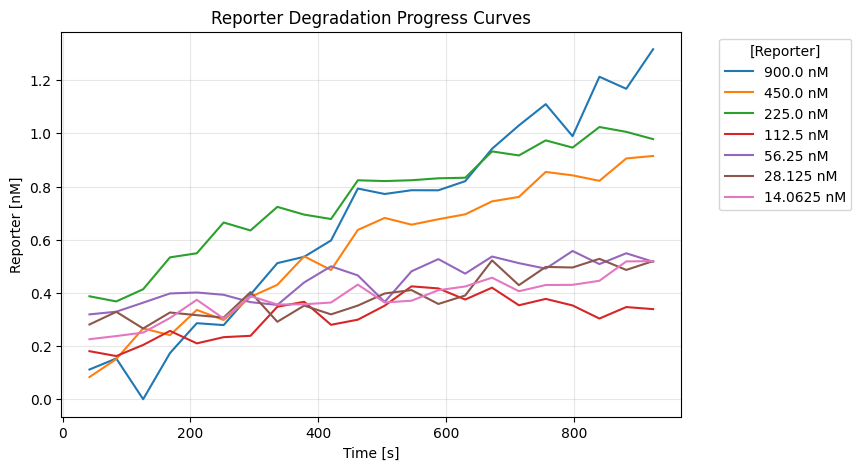

In [36]:
# @title 2.4.1 Upload and Plot Degradation Data.
print("Upload your reporter degradation spreadsheet (data in nM):")
uploaded_deg = files.upload()
deg_file_name = list(uploaded_deg.keys())[0]

if deg_file_name.endswith((".xlsx", ".xls")):
    df_deg = pd.read_excel(deg_file_name)
else:
    df_deg = pd.read_csv(deg_file_name)

# Find the Time column and identify data columns
time_col_deg = [c for c in df_deg.columns if 'time' in str(c).lower()][0]

# Identify the empty row separating data from concentrations
# Similar to Script 4, we find where numeric data ends
first_empty_row = df_deg[df_deg[time_col_deg].isna()].index[0]
clean_df_deg = df_deg.iloc[:first_empty_row].copy()
conc_row = df_deg.iloc[first_empty_row + 1]

# Map concentrations
wells_deg = [c for c in df_deg.columns if c != time_col_deg and 'unnamed' not in str(c).lower()]
conc_map_deg = {w: float(conc_row[w]) for w in wells_deg if pd.notna(conc_row[w])}

# Plot Progress Curves
plt.figure(figsize=(8, 5))
for w in conc_map_deg:
    plt.plot(clean_df_deg[time_col_deg], clean_df_deg[w], label=f"{conc_map_deg[w]} nM")
plt.xlabel("Time [s]")
plt.ylabel("Reporter [nM]")
plt.title("Reporter Degradation Progress Curves")
plt.legend(title="[Reporter]", bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()

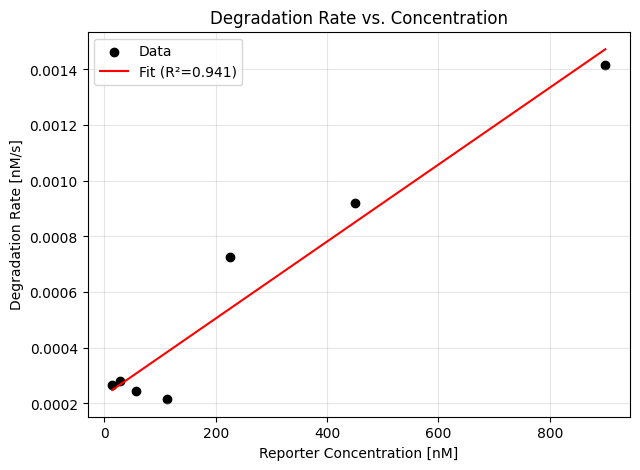

Reporter Degradation Rate (k_rep): 1.38e-06 s⁻¹


In [37]:
# @title 2.4.2 Calculate $k_{rep}$ via Linear Fitting
deg_results = []
t_deg = clean_df_deg[time_col_deg].values.astype(float)

for w, s0 in conc_map_deg.items():
    y_deg = clean_df_deg[w].values.astype(float)
    # Extract rate using the whole time span
    slope, intercept, r_val, p_val, std_err = linregress(t_deg, y_deg)
    deg_results.append({"Concentration": s0, "Rate": slope})

deg_df = pd.DataFrame(deg_results)

# Plot Rate vs Concentration
plt.figure(figsize=(7, 5))
plt.scatter(deg_df["Concentration"], deg_df["Rate"], color='black', label="Data")

# Linear fit for k_rep
k_slope, k_intercept, k_r, k_p, k_se = linregress(deg_df["Concentration"], deg_df["Rate"])
plt.plot(deg_df["Concentration"], k_slope * deg_df["Concentration"] + k_intercept, 'r-', label=f"Fit (R²={k_r**2:.3f})")

plt.xlabel("Reporter Concentration [nM]")
plt.ylabel("Degradation Rate [nM/s]")
plt.title("Degradation Rate vs. Concentration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Reporter Degradation Rate (k_rep): {k_slope:.3g} s⁻¹")

# **3. Script 3: Michaelis-Menten kinetic rate calculation and self-consistency checks**
Processes substrate-titration progress curves: extracts initial reaction rates by linear
regression over the first few cycles, fits the Michaelis-Menten model to obtain `Vmax`
and `Km`, derives `kcat` from your input `E0`, and runs the alpha/beta/gamma
self-consistency check.

## 3.1 Upload progress curve data (varying substrate)

**Kinetic Data Acquisition.** Upload the substrate-titration spreadsheet **after** signal-to-concentration conversion
(values must be in nM). This data will be used to generate the progress curves for Michaelis-Menten fitting.

Upload your spreadsheet with varying substrate (data in nM)…


Saving VaryingSubstrate.xlsx to VaryingSubstrate (2).xlsx


/tmp/ipykernel_27630/1535143873.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r', len(unique_s0s)) # Changed to viridis_r


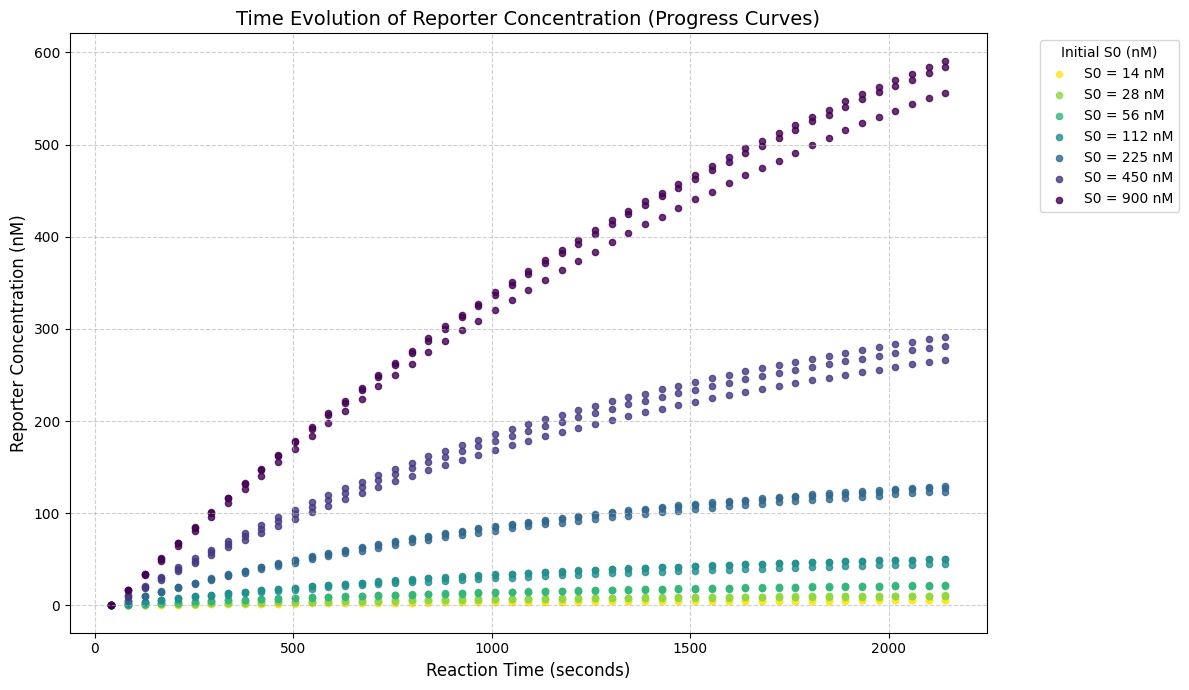

In [7]:
# @title
# Upload your spreadsheet of progress curves at varying substrate concentration [S0].
# IMPORTANT: data should already be converted to reporter concentration (in nM)
# using the calibration from Section 2.
# Expected layout: a "Time [s]" column, replicate well columns, and a row labeled
# "Substrate" giving each replicate's S0 in nM.

from google.colab import files
print("Upload your spreadsheet with varying substrate (data in nM)…")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.endswith(".xlsx") or file_name.endswith(".xls"):
    df = pd.read_excel(file_name)
elif file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    raise ValueError("Please upload an Excel or CSV file.")

def plot_progress_curves(df, first_data_col=2, time_col="Time [s]"):
    first_col = df.columns[0]
    sub_row_df = df[df[first_col].astype(str).str.strip().str.lower() == "substrate"]

    if sub_row_df.empty:
        raise ValueError("Could not find a row labeled 'Substrate' in the uploaded file.")

    sub_row = sub_row_df.iloc[0]
    data_cols = [col for col in df.columns[first_data_col:] if pd.notna(sub_row[col])]

    substrate_map = {}
    for col in data_cols:
        substrate_map[col] = float(sub_row[col])

    clean_df = df.copy()
    clean_df = clean_df.drop(sub_row_df.index) # Remove the substrate row
    clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
    clean_df = clean_df[clean_df[time_col].notna()].copy()

    for col in data_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
    clean_df = clean_df.reset_index(drop=True)

    time_points = clean_df[time_col].to_numpy()

    plt.figure(figsize=(12, 7))

    unique_s0s = sorted(list(set(substrate_map.values())))
    cmap = cm.get_cmap('viridis_r', len(unique_s0s)) # Changed to viridis_r

    wells_by_s0 = {}
    for well, s0 in substrate_map.items():
        if s0 not in wells_by_s0:
            wells_by_s0[s0] = []
        wells_by_s0[s0].append(well)

    for i, s0_val in enumerate(unique_s0s):
        color = cmap(i)
        current_wells = wells_by_s0.get(s0_val, [])
        for well in current_wells:
            if well in clean_df.columns:
                plt.scatter(time_points, clean_df[well], color=color, s=20,
                            label=f'S0 = {s0_val:.0f} nM' if well == current_wells[0] else "", alpha=0.8)

    plt.xlabel("Reaction Time (seconds)", fontsize=12)
    plt.ylabel("Reporter Concentration (nM)", fontsize=12)
    plt.title("Time Evolution of Reporter Concentration (Progress Curves)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Initial S0 (nM)", loc='best', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

# plot the progress curves
first_data_col = 2
time_col = "Time [s]"
plot_progress_curves(df, first_data_col, time_col)


## 3.2 Extract initial reaction rate

,Replicate,Substrate_nM,Initial_Rate_nM_per_s,R_squared,p_value,Slope_SE
18,P6,14.0625,0.005489,0.999042,1.258356e-05,0.000098
19,P7,14.0625,0.005360,0.990629,3.861144e-04,0.000301
20,P8,14.0625,0.005666,0.991469,3.352917e-04,0.000303
15,N6,28.1250,0.009887,0.995656,1.216716e-04,0.000377
16,N7,28.1250,0.009134,0.995051,1.479751e-04,0.000372
17,N8,28.1250,0.010001,0.996901,7.329788e-05,0.000322
12,L6,56.2500,0.019921,0.997918,4.035651e-05,0.000525
13,L7,56.2500,0.018901,0.997545,5.167949e-05,0.000541
14,L8,56.2500,0.019658,0.997372,5.722701e-05,0.000583
9,J6,112.5000,0.047481,0.999704,2.165462e-06,0.000472


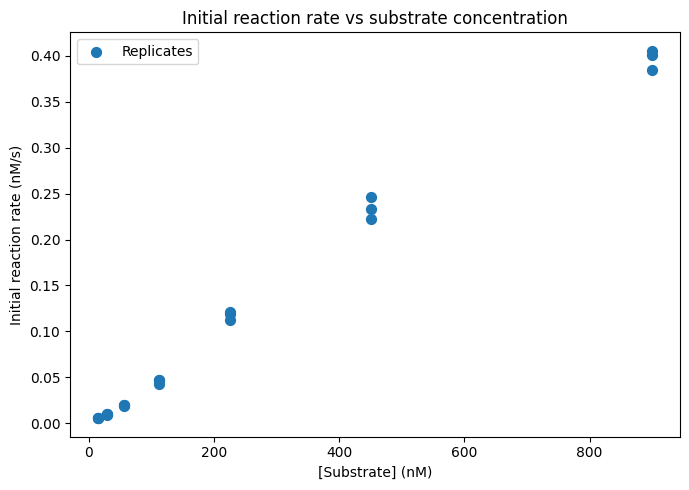

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import linregress

def calculate_initial_rates(df, time_col="Time [s]", first_data_col=2, first_n_cycles=5):
    """
    Assumes:
    - one row contains substrate concentrations, labeled 'Substrate' in first column
    - time column is named like 'Time [s]'
    - replicate data start from first_data_col
    """

    # ---------- 1. get substrate map from 'Substrate' row ----------
    first_col = df.columns[0]
    sub_row = df[df[first_col].astype(str).str.strip().str.lower() == "substrate"]

    if sub_row.empty:
        raise ValueError("Could not find a row labeled 'Substrate'.")

    sub_row = sub_row.iloc[0]
    data_cols = list(df.columns[first_data_col:])

    substrate_map = {}
    for col in data_cols:
        if pd.notna(sub_row[col]):
            substrate_map[col] = float(sub_row[col])

    # ---------- 2. clean numeric data ----------
    clean_df = df.copy()
    clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
    clean_df = clean_df[clean_df[time_col].notna()].copy()

    for col in data_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

    clean_df = clean_df.reset_index(drop=True)

    # ---------- 3. use first N cycles ----------
    fit_df = clean_df.iloc[:first_n_cycles].copy()
    t = fit_df[time_col].to_numpy()

    results = []
    for col in data_cols:
        if col not in substrate_map:
            continue

        y = fit_df[col].to_numpy()

        if np.any(pd.isna(y)):
            continue

        fit = linregress(t, y)

        results.append({
            "Replicate": col,
            "Substrate_nM": substrate_map[col],
            "Initial_Rate_nM_per_s": fit.slope,
            "R_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "Slope_SE": fit.stderr
        })

    replicate_rate_df = pd.DataFrame(results).sort_values(["Substrate_nM", "Replicate"])

    grouped_rate_df = (
        replicate_rate_df.groupby("Substrate_nM", as_index=False)
        .agg(
            Mean_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "mean"),
            SD_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "std"),
            N=("Initial_Rate_nM_per_s", "count")
        )
        .sort_values("Substrate_nM")
        .reset_index(drop=True)
    )

    return replicate_rate_df, grouped_rate_df

def plot_initial_rates(replicate_rate_df):
    plt.figure(figsize=(7,5))

    plt.scatter(
        replicate_rate_df["Substrate_nM"],
        replicate_rate_df["Initial_Rate_nM_per_s"],
        s=50,
        label="Replicates"
    )

    plt.xlabel("[Substrate] (nM)")
    plt.ylabel("Initial reaction rate (nM/s)")
    plt.title("Initial reaction rate vs substrate concentration")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- User-configurable parameter ---
first_n_cycles_for_initial_rate = 5 # @param {"type":"integer"}

replicate_rate_df, grouped_rate_df = calculate_initial_rates(df, first_n_cycles=first_n_cycles_for_initial_rate)

# display(df)
display(replicate_rate_df)

plot_initial_rates(replicate_rate_df)

## 3.3 Michaelis-Menten analysis

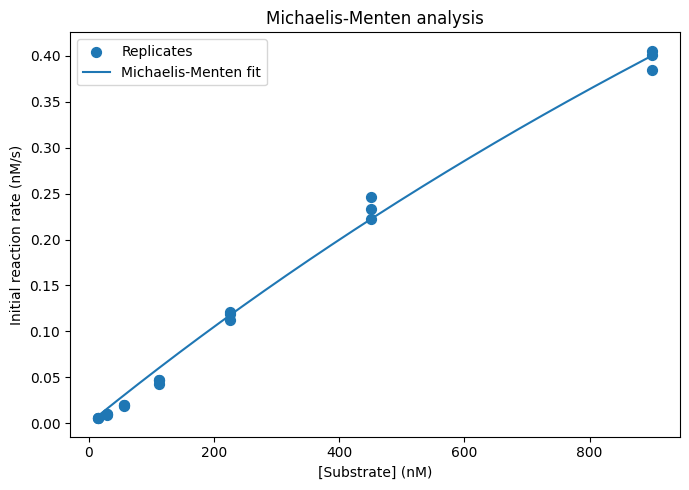

Vmax = 2.03
Km = 3.66e+03
95% CI Vmax: (1.11, 2.95)
95% CI Km: (1.67e+03, 5.65e+03)
R² = 0.994
Sum of Squares = 0.0022
Sy.x = 0.0108
SD replicates = 0.00649
SD lack of fit = 0.0179
F = 7.65
P value = 0.00119


In [14]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import f, t


# Michaelis-Menten model
def mm_model(S, Vmax, Km):
    S = np.asarray(S, dtype=float)
    return Vmax * S / (Km + S)


def run_mm_analysis_from_replicates(replicate_rate_df, make_plot=True):
    """
    Perform Michaelis-Menten analysis directly from replicate_rate_df.

    Required columns in replicate_rate_df:
    - Substrate_nM
    - Initial_Rate_nM_per_s

    Returns
    -------
    results_dict : dict
        Contains fitted parameters, statistics, and tables
    """

    # -------------------------
    # 1. Extract S and v
    # -------------------------
    df = replicate_rate_df.copy()

    if "Substrate_nM" not in df.columns or "Initial_Rate_nM_per_s" not in df.columns:
        raise ValueError("replicate_rate_df must contain 'Substrate_nM' and 'Initial_Rate_nM_per_s'.")

    df = df[["Substrate_nM", "Initial_Rate_nM_per_s"]].dropna().copy()
    df = df.sort_values("Substrate_nM").reset_index(drop=True)

    S = df["Substrate_nM"].to_numpy(dtype=float)
    v = df["Initial_Rate_nM_per_s"].to_numpy(dtype=float)

    if len(S) < 3:
        raise ValueError("Not enough data points for Michaelis-Menten fitting.")

    # -------------------------
    # 2. Nonlinear regression
    # -------------------------
    p0 = [np.max(v), np.median(S)]
    popt, pcov = curve_fit(mm_model, S, v, p0=p0, maxfev=10000)

    Vmax, Km = popt
    perr = np.sqrt(np.diag(pcov))
    Vmax_se, Km_se = perr

    # Predictions
    v_fit = mm_model(S, Vmax, Km)

    # -------------------------
    # 3. Goodness of fit
    # -------------------------
    residuals = v - v_fit
    SS_res = np.sum(residuals**2)
    SS_tot = np.sum((v - np.mean(v))**2)

    R2 = 1 - SS_res / SS_tot if SS_tot != 0 else np.nan

    n = len(v)
    p = 2
    dof = n - p

    Syx = np.sqrt(SS_res / dof) if dof > 0 else np.nan

    # -------------------------
    # 4. 95% confidence intervals
    # -------------------------
    tval = t.ppf(0.975, dof) if dof > 0 else np.nan

    Vmax_CI = (Vmax - tval * Vmax_se, Vmax + tval * Vmax_se) if dof > 0 else (np.nan, np.nan)
    Km_CI = (Km - tval * Km_se, Km + tval * Km_se) if dof > 0 else (np.nan, np.nan)

    # -------------------------
    # 5. Replicates test / lack of fit
    # -------------------------
    unique_S = np.unique(S)

    SS_pe = 0.0
    df_pe = 0

    for s in unique_S:
        vals = v[S == s]
        if len(vals) > 1:
            mean_val = np.mean(vals)
            SS_pe += np.sum((vals - mean_val)**2)
            df_pe += len(vals) - 1

    SS_lof = SS_res - SS_pe
    df_lof = dof - df_pe

    if df_pe > 0:
        MS_pe = SS_pe / df_pe
        SD_replicates = np.sqrt(MS_pe)
    else:
        MS_pe = np.nan
        SD_replicates = np.nan

    if df_lof > 0:
        MS_lof = SS_lof / df_lof
        SD_lof = np.sqrt(MS_lof) if MS_lof >= 0 else np.nan
    else:
        MS_lof = np.nan
        SD_lof = np.nan

    if df_pe > 0 and df_lof > 0 and MS_pe > 0:
        F_value = MS_lof / MS_pe
        p_value = 1 - f.cdf(F_value, df_lof, df_pe)
    else:
        F_value = np.nan
        p_value = np.nan

    # -------------------------
    # 6. Grouped summary table
    # -------------------------
    grouped_rate_df = (
        df.groupby("Substrate_nM", as_index=False)
        .agg(
            Mean_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "mean"),
            SD_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "std"),
            N=("Initial_Rate_nM_per_s", "count")
        )
        .sort_values("Substrate_nM")
        .reset_index(drop=True)
    )

    # Predicted curve for smooth plotting
    S_curve = np.linspace(np.min(S), np.max(S), 300)
    v_curve = mm_model(S_curve, Vmax, Km)

    # -------------------------
    # 7. Plot
    # -------------------------
    if make_plot:
        plt.figure(figsize=(7, 5))

        # replicate points
        plt.scatter(
            S,
            v,
            s=50,
            label="Replicates"
        )

        # fitted MM curve
        plt.plot(
            S_curve,
            v_curve,
            label="Michaelis-Menten fit"
        )

        plt.xlabel("[Substrate] (nM)")
        plt.ylabel("Initial reaction rate (nM/s)")
        plt.title("Michaelis-Menten analysis")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 8. Results table
    # -------------------------
    summary_df = pd.DataFrame({
        "Parameter": [
            "Vmax",
            "Km",
            "Vmax_SE",
            "Km_SE",
            "Vmax_95CI_lower",
            "Vmax_95CI_upper",
            "Km_95CI_lower",
            "Km_95CI_upper",
            "R_squared",
            "SS_res",
            "Sy.x",
            "SD_replicates",
            "SD_lack_of_fit",
            "F_value",
            "P_value_replicates_test"
        ],
        "Value": [
            Vmax,
            Km,
            Vmax_se,
            Km_se,
            Vmax_CI[0],
            Vmax_CI[1],
            Km_CI[0],
            Km_CI[1],
            R2,
            SS_res,
            Syx,
            SD_replicates,
            SD_lof,
            F_value,
            p_value
        ]
    })

    # Print concise summary
    print(f"Vmax = {Vmax:.3g}")
    print(f"Km = {Km:.3g}")
    print(f"95% CI Vmax: ({Vmax_CI[0]:.3g}, {Vmax_CI[1]:.3g})")
    print(f"95% CI Km: ({Km_CI[0]:.3g}, {Km_CI[1]:.3g})")
    print(f"R² = {R2:.3g}")
    print(f"Sum of Squares = {SS_res:.3g}")
    print(f"Sy.x = {Syx:.3g}")
    print(f"SD replicates = {SD_replicates:.3g}")
    print(f"SD lack of fit = {SD_lof:.3g}")
    print(f"F = {F_value:.3g}")
    print(f"P value = {p_value:.3g}")

    return {
        "input_df": df,
        "grouped_rate_df": grouped_rate_df,
        "summary_df": summary_df,
        "Vmax": Vmax,
        "Km": Km,
        "Vmax_SE": Vmax_se,
        "Km_SE": Km_se,
        "Vmax_CI": Vmax_CI,
        "Km_CI": Km_CI,
        "R_squared": R2,
        "SS_res": SS_res,
        "Syx": Syx,
        "SD_replicates": SD_replicates,
        "SD_lack_of_fit": SD_lof,
        "F_value": F_value,
        "P_value": p_value,
        "S_curve": S_curve,
        "v_curve": v_curve
    }
mm_results = run_mm_analysis_from_replicates(replicate_rate_df, make_plot=True)

## 3.4 Self-consistency check for alpha, beta, gamma

Extracts the derived variables (`max_mean_reaction_velocity`, `S0_at_max_velocity`,
`t_lin_max`), prompts you for `E0` to compute `kcat`, then evaluates the three
dimensionless self-consistency parameters alpha, beta, gamma.

In [27]:
# @title 3.4.1 Extract derived variables, compute kcat
# Assuming 'df', 'time_col', and 'first_n_cycles' are already defined in the global scope
# from previous cell executions.

# Define time_col and first_n_cycles explicitly for this cell's scope if not globally defined
time_col = "Time [s]"
first_n_cycles = first_n_cycles_for_initial_rate

# Recreate clean_df from the global df, as it was created inside a function previously
clean_df = df.copy()
clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
clean_df = clean_df[clean_df[time_col].notna()].copy()

# Identify data columns and convert them to numeric, similar to calculate_initial_rates
first_data_col = 2 # Default value from calculate_initial_rates function
data_cols = list(df.columns[first_data_col:])
for col in data_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
clean_df = clean_df.reset_index(drop=True)

# Extract the time points for the initial n cycles
fit_df = clean_df.iloc[:first_n_cycles].copy()
t_lin = fit_df[time_col].to_numpy()

# Extract and print only the maximum t_lin value
t_lin_max = t_lin.max()
print(f"Maximum time point for initial rate calculation (t_lin_max): {t_lin_max} s")

# Extract the maximum reaction velocity and its corresponding substrate concentration
max_rate_row = grouped_rate_df.loc[grouped_rate_df['Mean_Initial_Rate_nM_per_s'].idxmax()]

max_mean_reaction_velocity = max_rate_row['Mean_Initial_Rate_nM_per_s']
S0_at_max_velocity = max_rate_row['Substrate_nM']

print(f"Reported Max Initial Reaction Rate: {max_mean_reaction_velocity:.4f} nM/s")
print(f"Substrate Concentration (S0) at Max Rate: {S0_at_max_velocity:.2f} nM")

# Initialize Vmax and Km to None in case mm_results is not defined
Vmax = None
Km = None

try:
    # Extract Vmax and KM
    print(f"Vmax: {mm_results['Vmax']:.4f} nM/s")
    print(f"KM: {mm_results['Km']:.2f} nM")

    # Extract Vmax and Km from the mm_results dictionary
    Vmax = mm_results['Vmax']
    Km = mm_results['Km']

except NameError:
    print("Error: The 'mm_results' variable is not defined. Please ensure the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K) has been executed before running this cell.")
except KeyError as e:
    print(f"Error: Missing key '{e}' in mm_results dictionary. Please check the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K).")


# Ask the user for the initial enzyme concentration (E0)
E0_str = input("Please enter the fixed concentration (nM) of E0: ")

try:
    E0 = float(E0_str)
    if E0 <= 0:
        raise ValueError("E0 must be a positive value.")
except ValueError as e:
    print(f"Invalid input for E0: {e}")
    print("Please run this cell again and enter a valid positive number for E0.")
    E0 = None # Set E0 to None to prevent further calculations if invalid

if E0 is not None and Vmax is not None: # Add check for Vmax
    # Calculate kcat
    kcat = Vmax / E0
    print(f"\nCalculated kcat = {kcat:.4f} 1/s (Vmax in nM/s and E0 in nM).")
else:
    if Vmax is None:
        print("\nkcat cannot be calculated because Vmax is not available. Please address the error regarding 'mm_results'.")
    elif E0 is None:
        print("\nkcat cannot be calculated because E0 is not valid.")


Maximum time point for initial rate calculation (t_lin_max): 210.0 s
Reported Max Initial Reaction Rate: 0.3970 nM/s
Substrate Concentration (S0) at Max Rate: 900.00 nM
Vmax: 2.0275 nM/s
KM: 3659.34 nM
Please enter the fixed concentration (nM) of E0: 1

Calculated kcat = 2.0275 1/s (Vmax in nM/s and E0 in nM).


In [28]:
# @title 3.4.2 Self-consistency check of alpha, beta, gamma
import numpy as np

try:
    # Extract Vmax and Km from mm_results dictionary
    Vmax = mm_results['Vmax']
    Km = mm_results['Km']

    # Calculate alpha, beta, and gamma
    alpha = max_mean_reaction_velocity * t_lin_max / S0_at_max_velocity
    beta = max_mean_reaction_velocity / Vmax
    gamma = t_lin_max * Vmax / (Km + S0_at_max_velocity * (1 - 1/np.e))

    print(f"alpha = {alpha:.4f}")
    print(f"beta = {beta:.4f}")
    print(f"gamma = {gamma:.4f}")
except NameError:
    print("Error: The 'mm_results' variable is not defined. Please ensure the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K) has been executed before running this cell.")
except KeyError:
    print("Error: 'Vmax' or 'Km' not found in 'mm_results'. Please check the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

alpha = 0.0926
beta = 0.1958
gamma = 0.1007


# **4. Script 4: Determination of limit of detection**

Processes target-titration progress curves and derives two limits of detection:
the **endpoint LoD `L_e`** (interpolated on the endpoint-signal curve at
`mean_NTC + 3*SD`) and the **rate-based LoD `L_v`** (interpolated on the initial-rate
curve at the same threshold).

## 4.1 Upload progress curve data (varying target)

Upload the target-titration spreadsheet **after** signal-to-concentration conversion
(values must be in nM).

In [29]:
# @title
print("Upload your 'Varying Target Concentration' spreadsheet (data in nM):")
uploaded = files.upload()

target_file_name = list(uploaded.keys())[0]
print("Varying Target Concentration file set to:", target_file_name)

if target_file_name.endswith(".xlsx") or target_file_name.endswith(".xls"):
    df_tar = pd.read_excel(target_file_name)
elif target_file_name.endswith(".csv"):
    df_tar = pd.read_csv(target_file_name)
else:
    raise ValueError("Please upload an Excel (.xlsx, .xls) or CSV (.csv) file for Varying Target Concentration.")

print(f"df_tar loaded with shape: {df_tar.shape}")
display(df_tar.head())

Upload your 'Varying Target Concentration' spreadsheet (data in nM):


Saving VaryingTarget.xlsx to VaryingTarget.xlsx
Varying Target Concentration file set to: VaryingTarget.xlsx
df_tar loaded with shape: (53, 23)


,Unnamed: 0,Time [s],D2,D3,D4,F2,F3,F4,H2,H3,...,J4,L2,L3,L4,N2,N3,N4,P2,P3,P4
0,0,42.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025810,0.000000,...,0.000000,0.000000,0.059078,0.000000,0.000000,0.000000,0.041556,0.000000,0.054272,0.108596
1,1,84.0,1.326535,1.332337,1.490683,0.081980,0.126945,0.162862,0.000000,0.019540,...,0.013938,0.036748,0.000000,0.008588,0.015942,0.046691,0.000000,0.109192,0.000000,0.009843
2,2,126.0,2.837988,2.476689,2.988260,0.320674,0.231852,0.281141,0.097964,0.032890,...,0.037422,0.048560,0.052159,0.042544,0.015738,0.140609,0.062123,0.106904,0.057849,0.000000
3,3,168.0,4.136411,3.653279,4.428380,0.435921,0.346098,0.407657,0.031722,0.036366,...,0.079319,0.071145,0.111303,0.054487,0.023111,0.110647,0.015794,0.146309,0.046619,0.068578
4,4,210.0,5.399532,4.820133,5.802226,0.620466,0.538633,0.558231,0.096687,0.125282,...,0.077564,0.141538,0.118661,0.112701,0.067511,0.125112,0.084097,0.235668,0.060191,0.111763


## 4.2 Extract endpoint signals

In [30]:
# @title
first_col = df_tar.columns[0]
target_row_df = df_tar[df_tar[first_col].astype(str).str.strip().str.lower().str.contains("target")]

# Assuming time_col is already defined from previous cells
# If not, let's define it based on common practice or inspect df_tar
if 'Time [s]' in df_tar.columns:
    time_col = 'Time [s]'
elif 'Time' in df_tar.columns:
    time_col = 'Time'
else:
    # Fallback if neither 'Time [s]' nor 'Time' is found in df_tar
    # This might need adjustment based on actual df_tar structure
    time_col = df_tar.columns[1] # Assuming time is the second column

# Identify data columns (wells) excluding the first column and the time column
data_cols_tar = [col for col in df_tar.columns if col != first_col and col != time_col]

target_concentration_map = {}
endpoint_signals = {} # Renamed from endpoint_concentrations

target_row_index = -1
if not target_row_df.empty:
    target_row_tar = target_row_df.iloc[0]
    target_row_index = target_row_tar.name # Get the actual index of the target row

    for col in data_cols_tar:
        # Extract Target Concentration
        if pd.notna(target_row_tar[col]):
            target_concentration_map[col] = float(target_row_tar[col])
        else:
            target_concentration_map[col] = np.nan # Handle missing target concentration
else:
    print("Warning: Could not find a row labeled 'Target' in df_tar. Target concentrations will be set to NaN.")
    for col in data_cols_tar:
        target_concentration_map[col] = np.nan

for col in data_cols_tar:
    # Extract Endpoint Signal (last value in the time-series data, BEFORE the target row)
    if target_row_index != -1:
        # Time-series data is from row 0 up to target_row_index - 1
        relevant_data = df_tar[col].iloc[:target_row_index]
    else:
        # If no target row, assume all data is time-series
        relevant_data = df_tar[col]

    numeric_values = pd.to_numeric(relevant_data, errors='coerce').dropna()
    if not numeric_values.empty:
        endpoint_signals[col] = numeric_values.iloc[-1]
    else:
        endpoint_signals[col] = np.nan

# Create a new DataFrame
results_list = []
for well in data_cols_tar:
    results_list.append({
        'Well': well,
        'Target_Concentration_nM': target_concentration_map.get(well),
        'Endpoint_Signal_AU': endpoint_signals.get(well) # Renamed column
    })

target_endpoint_df = pd.DataFrame(results_list)

print("Extracted Target Concentrations and Endpoint Signals:") # Updated print statement
display(target_endpoint_df.head())

Extracted Target Concentrations and Endpoint Signals:


,Well,Target_Concentration_nM,Endpoint_Signal_AU
0,D2,10.0,43.907516
1,D3,10.0,40.120748
2,D4,10.0,47.700965
3,F2,1.0,6.076316
4,F3,1.0,5.337113


## 4.3 Determine endpoint LoD Le

Mean Endpoint Signal for lowest target concentration (1.00e-05 nM): 0.5657 nM
Standard Deviation of Endpoint Signal for lowest target concentration (1.00e-05 nM): 0.0339 nM
Endpoint Threshold Value (P_thr): 0.6675 nM


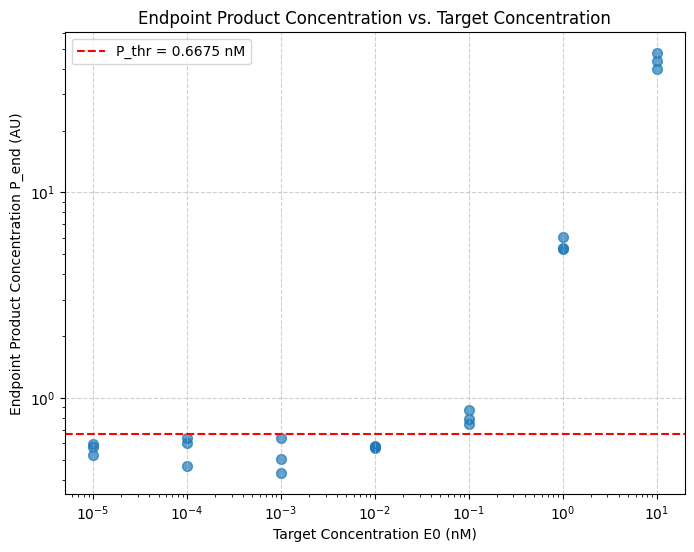

In [31]:
# @title 4.3.1 Calculate NTC threshold and plot
import matplotlib.pyplot as plt

# Find the smallest target concentration (which might not be 0)
min_target_concentration = target_endpoint_df['Target_Concentration_nM'].min()

# Filter for data corresponding to the smallest target concentration
ntc_data = target_endpoint_df[target_endpoint_df['Target_Concentration_nM'] == min_target_concentration]

# Calculate the mean of Endpoint_Signal_AU for ntc_data
mean_ntc_signal = ntc_data['Endpoint_Signal_AU'].mean()

# Calculate the standard deviation of Endpoint_Signal_AU for ntc_data
std_ntc_signal = ntc_data['Endpoint_Signal_AU'].std()

# Calculate the threshold value (P_thr) using the provided formula
P_thr = mean_ntc_signal + 3 * std_ntc_signal

# Conditional printing based on min_target_concentration
if min_target_concentration == 0:
    print(f"Mean Endpoint Signal for E0=0 (P(E0=0)): {mean_ntc_signal:.4f} nM")
    print(f"Standard Deviation of Endpoint Signal for E0=0 (STD(E0=0)): {std_ntc_signal:.4f} nM")
    print(f"Endpoint Threshold Value (P_thr): {P_thr:.4f} nM")
else:
    print(f"Mean Endpoint Signal for lowest target concentration ({min_target_concentration:.2e} nM): {mean_ntc_signal:.4f} nM")
    print(f"Standard Deviation of Endpoint Signal for lowest target concentration ({min_target_concentration:.2e} nM): {std_ntc_signal:.4f} nM")
    print(f"Endpoint Threshold Value (P_thr): {P_thr:.4f} nM")

plt.figure(figsize=(8, 6))
plt.scatter(target_endpoint_df['Target_Concentration_nM'], target_endpoint_df['Endpoint_Signal_AU'], s=50, alpha=0.7)
plt.xscale('log') # Set x-axis to logarithmic scale
plt.yscale('log')
plt.xlabel("Target Concentration E0 (nM)")
plt.ylabel("Endpoint Product Concentration P_end (AU)")
plt.title("Endpoint Product Concentration vs. Target Concentration")
plt.grid(True, linestyle='--', alpha=0.6)

# Draw a horizontal line at y = P_thr
plt.axhline(y=P_thr, color='r', linestyle='--', label=f'P_thr = {P_thr:.4f} nM')
plt.legend()

plt.show()

In [32]:
# @title 4.3.2 Determine endpoint LoD Le (interpolate at endpoint threshold)
from scipy.interpolate import interp1d
import numpy as np

# Prepare data for interpolation
# Ensure data is sorted by target concentration for correct interpolation
sorted_data = target_endpoint_df.sort_values(by='Target_Concentration_nM').reset_index(drop=True)

x_values = sorted_data['Target_Concentration_nM'].to_numpy()
y_values = sorted_data['Endpoint_Signal_AU'].to_numpy()

# Filter out NaN values from both arrays, keeping corresponding pairs
valid_indices = ~np.isnan(x_values) & ~np.isnan(y_values)
x_values = x_values[valid_indices]
y_values = y_values[valid_indices]

# Ensure there are enough points for interpolation
if len(x_values) < 2:
    print("Not enough valid data points for interpolation to determine LoD.")
    LoD = np.nan
else:
    # Create an interpolation function: y = f(x)
    # Since we want x (Target_Concentration) for a given y (P_thr), we interpolate x as a function of y.
    # Handle cases where P_thr might be outside the range of y_values
    if P_thr < np.min(y_values):
        print(f"P_thr ({P_thr:.4f}) is below the minimum Endpoint Signal ({np.min(y_values):.4f}). LoD cannot be accurately determined by interpolation below data range.")
        LoD = np.nan
    elif P_thr > np.max(y_values):
        print(f"P_thr ({P_thr:.4f}) is above the maximum Endpoint Signal ({np.max(y_values):.4f}). LoD cannot be accurately determined by interpolation above data range.")
        LoD = np.nan
    else:
        # Ensure x_values (Target_Concentration_nM) are unique for interp1d when interpolating y to x
        # If not unique, average y_values for duplicate x_values, or use a specific interpolation strategy
        # For this context, we assume a monotonic relationship for LoD determination and interpolate X as a function of Y
        # To interpolate X as a function of Y, Y values should ideally be monotonic. If not, this can cause issues.
        # Let's assume we want to interpolate in the region where the curve is generally increasing.

        # To make Y monotonic for interpolation (Y_to_X), we might need to select a subset or ensure it's sorted.
        # For LoD, we are looking for a specific Y value (P_thr) corresponding to an X value.
        # Let's create an interpolation function from y to x
        f_interp = interp1d(y_values, x_values, kind='linear', fill_value="extrapolate")

        # Determine LoD by finding the target concentration at P_thr
        LoD = f_interp(P_thr)

print(f"\nCalculated Endpoint Limit of Detection (LoD): {LoD:.4f} nM")



Calculated Endpoint Limit of Detection (LoD): 0.0267 nM


## 4.4 Extract initial reaction rates

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# --- User-configurable parameter ---
first_n_cycles_for_initial_rate = 5 # @param {"type":"integer"}

def calculate_initial_rates_from_df_tar(df_tar, time_col="Time [s]", first_n_cycles=5):
    """
    Calculates initial reaction rates for each well in df_tar.
    Assumes:
    - one row contains target concentrations, labeled 'Target' in the first column (or containing 'target').
    - time column is named 'Time [s]'.
    - time-series data precedes the 'Target' row.
    """
    first_col = df_tar.columns[0]
    # Changed to use .str.contains("target") for consistency
    target_row_df = df_tar[df_tar[first_col].astype(str).str.strip().str.lower().str.contains("target")]

    target_concentration_map = {}
    # Identify data columns by excluding the first column and time_col
    data_cols_tar = [col for col in df_tar.columns if col != first_col and col != time_col]

    if not target_row_df.empty:
        target_row_tar = target_row_df.iloc[0]
        for col in data_cols_tar:
            if pd.notna(target_row_tar[col]):
                target_concentration_map[col] = float(target_row_tar[col])
            else:
                target_concentration_map[col] = np.nan # Handle missing target concentration
    else:
        print("Warning: Could not find a row containing 'Target'. Target concentrations will be set to NaN.")
        for col in data_cols_tar:
            target_concentration_map[col] = np.nan

    clean_df_tar = df_tar.copy()
    # Filter out the target row from the main dataframe before processing time-series data
    if not target_row_df.empty:
        clean_df_tar = clean_df_tar.drop(target_row_df.index)

    clean_df_tar[time_col] = pd.to_numeric(clean_df_tar[time_col], errors="coerce")
    clean_df_tar = clean_df_tar[clean_df_tar[time_col].notna()].copy() # Ensure time is valid

    for col in data_cols_tar:
        clean_df_tar[col] = pd.to_numeric(clean_df_tar[col], errors="coerce")

    clean_df_tar = clean_df_tar.reset_index(drop=True)

    # Use first N cycles for linear regression
    fit_df_tar = clean_df_tar.iloc[:first_n_cycles].copy()
    t = fit_df_tar[time_col].to_numpy()

    results = []
    for col in data_cols_tar:
        y = fit_df_tar[col].to_numpy()

        # Ensure there's enough non-NaN data for linear regression
        valid_indices = ~np.isnan(t) & ~np.isnan(y)
        t_valid = t[valid_indices]
        y_valid = y[valid_indices]

        if len(t_valid) < 2:
            initial_rate = np.nan
            r_squared = np.nan
        else:
            fit = linregress(t_valid, y_valid)
            initial_rate = fit.slope
            r_squared = fit.rvalue**2

        results.append({
            "Well": col,
            "Target_Concentration_nM": target_concentration_map.get(col, np.nan),
            "Initial_Rate_nM_per_s": initial_rate,
            "R_squared": r_squared,
        })

    replicate_rate_df_tar = pd.DataFrame(results)
    return replicate_rate_df_tar

# Call the function with df_tar and display the results
replicate_rate_df_tar = calculate_initial_rates_from_df_tar(df_tar, first_n_cycles=first_n_cycles_for_initial_rate)
print("Initial Reaction Rates from df_tar:")
display(replicate_rate_df_tar.head())

Initial Reaction Rates from df_tar:


,Well,Target_Concentration_nM,Initial_Rate_nM_per_s,R_squared
0,D2,10.0,0.032402,0.999038
1,D3,10.0,0.028479,0.999264
2,D4,10.0,0.034624,0.999686
3,F2,1.0,0.003797,0.982861
4,F3,1.0,0.003087,0.985707


## 4.5 Determine rate-based LoD Lv

Mean Initial Reaction Rate for lowest target concentration (0.0000 nM): 0.0005 nM/s
Standard Deviation of Initial Reaction Rate for lowest target concentration (0.0000 nM): 0.0006 nM/s
Rate-based Threshold (Rate_thr): 0.0023 nM/s


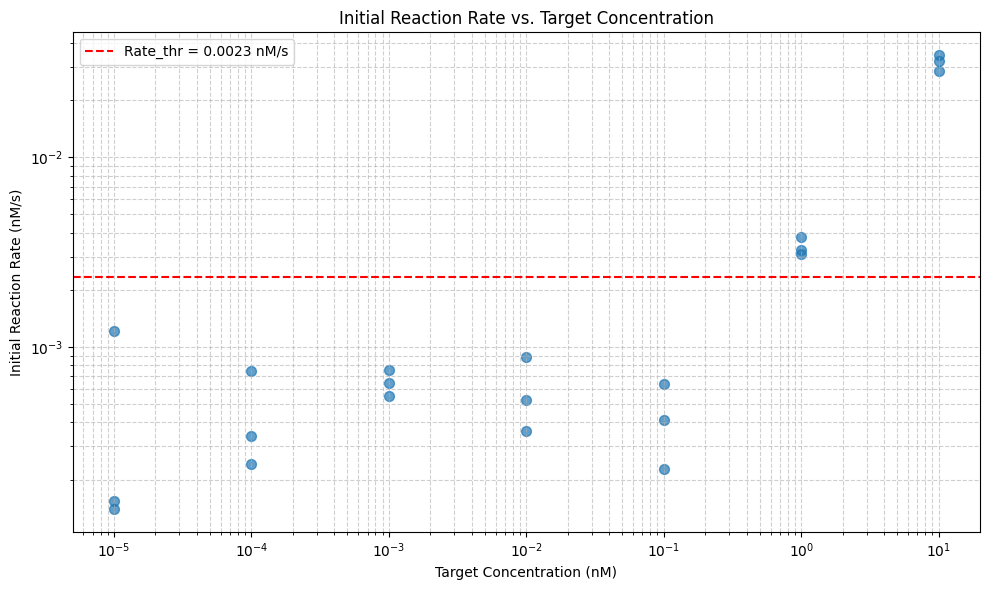

In [34]:
# @title 4.5.1 Calculate NTC threshold and plot
import numpy as np
import matplotlib.pyplot as plt # Import plt again, good practice for separate cells

# Find the smallest target concentration (which might not be 0)
min_target_concentration_rates = replicate_rate_df_tar['Target_Concentration_nM'].min()

# Filter for NTC (No Target Control) data where Target_Concentration_nM is the smallest
ntc_rates_data = replicate_rate_df_tar[replicate_rate_df_tar['Target_Concentration_nM'] == min_target_concentration_rates]

# Calculate the mean of 'Initial_Rate_nM_per_s' for NTC data
mean_ntc_rate = ntc_rates_data['Initial_Rate_nM_per_s'].mean()

# Calculate the standard deviation of 'Initial_Rate_nM_per_s' for NTC data
std_ntc_rate = ntc_rates_data['Initial_Rate_nM_per_s'].std()

# Compute the Rate_thr
Rate_thr = mean_ntc_rate + 3 * std_ntc_rate

# Conditional printing based on min_target_concentration_rates
if min_target_concentration_rates == 0:
    print(f"Mean Initial Reaction Rate for NTC (E0=0): {mean_ntc_rate:.4f} nM/s")
    print(f"Standard Deviation of Initial Reaction Rate for NTC (E0=0): {std_ntc_rate:.4f} nM/s")
    print(f"Rate-based Threshold (Rate_thr): {Rate_thr:.4f} nM/s")
else:
    print(f"Mean Initial Reaction Rate for lowest target concentration ({min_target_concentration_rates:.4f} nM): {mean_ntc_rate:.4f} nM/s")
    print(f"Standard Deviation of Initial Reaction Rate for lowest target concentration ({min_target_concentration_rates:.4f} nM): {std_ntc_rate:.4f} nM/s")
    print(f"Rate-based Threshold (Rate_thr): {Rate_thr:.4f} nM/s")

plt.figure(figsize=(10, 6))
plt.scatter(replicate_rate_df_tar['Target_Concentration_nM'], replicate_rate_df_tar['Initial_Rate_nM_per_s'], s=50, alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Target Concentration (nM)")
plt.ylabel("Initial Reaction Rate (nM/s)")
plt.title("Initial Reaction Rate vs. Target Concentration")
plt.grid(True, which="both", ls="--", alpha=0.6)

# Add horizontal line for Rate_thr
plt.axhline(y=Rate_thr, color='r', linestyle='--', label=f'Rate_thr = {Rate_thr:.4f} nM/s')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# @title 4.5.2 Determine rate-based LoD Lv (interpolate at rate threshold)
from scipy.interpolate import interp1d
import numpy as np

# Prepare data for interpolation
sorted_rates_data = replicate_rate_df_tar.sort_values(by='Target_Concentration_nM').reset_index(drop=True)

x_rates = sorted_rates_data['Initial_Rate_nM_per_s'].to_numpy()
y_concentrations = sorted_rates_data['Target_Concentration_nM'].to_numpy()

# Filter out NaN values from both arrays, keeping corresponding pairs
valid_indices = ~np.isnan(x_rates) & ~np.isnan(y_concentrations)
x_rates = x_rates[valid_indices]
y_concentrations = y_concentrations[valid_indices]

# Ensure there are enough points for interpolation
if len(x_rates) < 2:
    print("Not enough valid data points for interpolation to determine rate-based LoD.")
    rate_based_LoD = np.nan
elif Rate_thr < np.min(x_rates):
    print(f"Rate_thr ({Rate_thr:.4f}) is below the minimum Initial Reaction Rate ({np.min(x_rates):.4f}). Rate-based LoD cannot be accurately determined by interpolation below data range.")
    rate_based_LoD = np.nan
elif Rate_thr > np.max(x_rates):
    print(f"Rate_thr ({Rate_thr:.4f}) is above the maximum Initial Reaction Rate ({np.max(x_rates):.4f}). Rate-based LoD cannot be accurately determined by interpolation above data range.")
    rate_based_LoD = np.nan
else:
    # Create an interpolation function: concentration = f(rate)
    # Ensure x_rates are monotonic for interp1d
    # If there are duplicate x_rates, interp1d will raise an error if they are not strictly increasing.
    # For this specific case (LoD), we expect rates to generally increase with concentration.
    # If not strictly increasing, we can try to average y values for duplicate x values, or accept non-monotonicity if it makes sense.
    # For now, assuming x_rates are sufficiently unique or sorted to allow interpolation.
    f_interp_rate = interp1d(x_rates, y_concentrations, kind='linear', fill_value="extrapolate")

    # Determine rate-based LoD by finding the target concentration at Rate_thr
    rate_based_LoD = f_interp_rate(Rate_thr)

print(f"\nCalculated Rate-based Limit of Detection (LoD): {rate_based_LoD:.4f} nM")


Calculated Rate-based Limit of Detection (LoD): 0.6040 nM


## 4.6 Calculation of the theoretical LoD, Le and Lv

This section computes the theoretical limits of detection based on the kinetic parameters and experimental conditions established in previous sections.

In [42]:
# @title
import numpy as np

# 1. Get user input for S0
try:
    S0_input = float(input("Enter the substrate concentration S0 [nM]: "))
except ValueError:
    print("Invalid input. Please enter a numerical value for S0.")
    S0_input = None

if S0_input is not None:
    try:
        # 2. Gather parameters from previous sections
        # From Section 3.3 (Km)
        KM_val = mm_results['Km']

        # From Section 3.4.1 (kcat)
        # Note: kcat was calculated in 3.4.1 local scope but we have it in global if cell was run
        kcat_val = kcat

        # From Section 2.4.2 (krep)
        krep_val = k_slope

        # From Section 2.2 (Fcl, Fucl)
        Fcl_val = Fcl_fit
        Fucl_val = Fucl_fit

        # From Section 4.1 (t_max)
        # Extracting maximum time from df_tar
        t_max_val = pd.to_numeric(df_tar[time_col], errors='coerce').max()

        # 3. Perform Calculations
        # Lv = (KM + S0) * krep / kcat
        theo_Lv = (KM_val + S0_input) * krep_val / kcat_val

        # Le = (KM + S0) * ((Fcl - Fucl) * krep * t_max) / (-Fcl + (Fcl - Fucl) * kcat * t_max)
        numerator = (KM_val + S0_input) * ((Fcl_val - Fucl_val) * krep_val * t_max_val)
        denominator = (-Fcl_val + (Fcl_val - Fucl_val) * kcat_val * t_max_val)
        theo_Le = numerator / denominator

        # 4. Report results
        print("\n--- Theoretical LoD Results ---")
        print(f"Theoretical Rate-based LoD (Lv): {theo_Lv:.4g} nM")
        print(f"Theoretical Endpoint LoD (Le): {theo_Le:.4g} nM")

    except NameError as e:
        print(f"Error: A required parameter is missing. Please ensure sections 2.2, 2.4, 3.3, 3.4, and 4.1 have been executed. ({e})")
    except ZeroDivisionError:
        print("Error: Division by zero encountered in formula. Check your input values and fitted parameters.")

Enter the substrate concentration S0 [nM]: 1000

--- Theoretical LoD Results ---
Theoretical Rate-based LoD (Lv): 0.003176 nM
Theoretical Endpoint LoD (Le): 0.003177 nM
